In [17]:
import os
import openmc
import numpy as np
from IPython.display import Image, display
import matplotlib.pyplot as plt
from datetime import datetime


In [18]:
# pulizia per sicurezza

os.system("rm *.h5")
os.system("rm *.xml")
os.system("rm *.out")
os.system("rm *.png")

rm: cannot remove '*.h5': No such file or directory
rm: cannot remove '*.out': No such file or directory


0

VARIABILI IMPORTANTI

In [19]:
def load_parameters(filename='parametri.txt'):
    """
    Legge i parametri dal file txt e li restituisce come un dizionario.
    """
    params = {}
    # Forniamo np al contesto di esecuzione per gestire np.sqrt()
    context = {'np': np} 
    
    with open(filename, 'r') as f:
        code = f.read()
        exec(code, context, params)
    
    # Rimuoviamo 'np' e altri built-in dal dizionario finale
    return {k: v for k, v in params.items() if not k.startswith('__') and k != 'np'}

p = load_parameters('../parametri.txt')


# --- Parametri Geometrici ---
R_CORE    = p['R_CORE']
REF_SIDE  = p['REF_SIDE']
REF_BOT   = p['REF_BOT']
H_CORE    = p['H_CORE']

# --- Parametri Logici ---
R_PIPE    = p['R_PIPE']

# --- Parametri Pin/Lattice ---
R_FUEL    = p['R_FUEL']
CLAD_THICK= p['CLAD_THICK']
R_WATER_THICK = p['R_WATER_THICK']
R_PIN     = p['R_PIN']
PITCH     = p['PITCH']

# --- Parametri Target ---
R_TARGET  = p['R_TARGET']
H_TARGET  = p['H_TARGET']
P_TARGET  = p['P_TARGET']

# --- Sorgente e Simulazione ---
S             = p['S']

bin_ris       = p['bin_ris']

batches       = p['batches_auto']
particles     = p['particles_auto']
inactive      = p['inactive_auto']

arricchimento = p['arricchimento']
mix = p['mix_acqua']

MATERIALI

In [20]:
fuel = openmc.Material(name='fuel')
fuel.add_nuclide('U235', arricchimento)
fuel.add_nuclide('U238', 1.0 - arricchimento)
fuel.add_nuclide('O16', 2.0)
fuel.set_density('g/cm3', 10.96)

# materiale di rivestimento
cladding = openmc.Material (name = 'cladding')
cladding.add_element('Zr', 1.0) 
cladding.set_density('g/cm3', 6.49)

# materiale di moderatore
water = openmc.Material (name = 'water')
water.add_nuclide('H1', mix)
water.add_nuclide('H2', 1-mix)
water.add_element('O', 1.0)
water.set_density('g/cm3', 1.10)
water.add_s_alpha_beta('c_D_in_D2O') # aggiungo la tabella di scattering termico
# n.b.  le sezioni d'urto veloci sono già incluse di default


# aggiungo un riflettore 
reflector = openmc.Material(name='reflector')
reflector.add_element('C',1.0)
reflector.set_density('g/cm3', 1.75) 

# voglio una sorgente puntiforme di neutroni in un punto specifico
marker_mat = openmc.Material(name='marker')
marker_mat.set_density('g/cm3', 1e-10) # Densità quasi nulla per non disturbare la fisica
marker_mat.add_nuclide('He4', 1.0) # elio, non interagisce praticamente

void_air = openmc.Material(name='void_air')
void_air.set_density('g/cm3', 1e-10) # Densità
void_air.add_nuclide('N14', 1 )

mat_target = openmc.Material(name='mat_target')
mat_target.add_nuclide('U235', arricchimento)
mat_target.add_nuclide('U238', 1.0 - arricchimento)
mat_target.add_nuclide('O16', 2.0)
mat_target.set_density('g/cm3', 10.96)

materials = openmc.Materials([fuel, cladding, water, reflector, marker_mat, void_air, mat_target])

materials.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml" # per fotonucleari

materials.export_to_xml()

GEOMETRIA

In [21]:
# --- 0. PIANI Z (ASSOLUTI) ---
z_bot_ref = openmc.ZPlane(z0=-REF_BOT, boundary_type='vacuum')
z_bot_core = openmc.ZPlane(z0=0.0)
z_top_core = openmc.ZPlane(z0=H_CORE)
z_top_world = openmc.ZPlane(z0=H_CORE + 5.0, boundary_type='vacuum')

# Piani Z Target
z_mid = H_CORE - P_TARGET
z_tgt_bot = openmc.ZPlane(z0=z_mid - (H_TARGET / 2.0))
z_tgt_top = openmc.ZPlane(z0=z_mid + (H_TARGET / 2.0))

# Superficie Sorgente
sphere_src = openmc.Sphere(x0=0, y0=0, z0=H_CORE + 2, r=0.5)

# --- 1. CALCOLO DIMENSIONI TAGLIO CENTRALE ---
# Calcoliamo quanto deve essere grande il buco esagonale centrale
# Rimuoviamo gli anelli che cadono dentro R_PIPE
n_rings_removed = int(np.ceil(R_PIPE / PITCH))
# Il lato del prisma che useremo per "bucare" il lattice:
EDGE_PIPE_LARGE = (n_rings_removed - 0.5) * PITCH
if EDGE_PIPE_LARGE == 0: EDGE_PIPE_LARGE = PITCH # Sicurezza minima

# --- 2. FORME GEOMETRICHE BASE ---

EDGE_FUEL = R_FUEL
EDGE_CLAD = R_FUEL + CLAD_THICK

# A. Prismi PIN
hex_fuel_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_FUEL, orientation='x')
hex_clad_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_CLAD, orientation='x')

# B. Prisma "TAGLIO" CENTRALE (Il buco grande nel reticolo)
hex_pipe_prism = openmc.model.get_hexagonal_prism(edge_length=EDGE_PIPE_LARGE, orientation='x')

# C. Cilindro Target (Unico centrale)
cyl_target = openmc.ZCylinder(r=R_TARGET)


# --- 3. UNIVERSI ---

# A. Universo PIN (Fuel -> Clad -> Water)
c_fuel = openmc.Cell(fill=fuel, region=hex_fuel_prism)
c_clad = openmc.Cell(fill=cladding, region=hex_clad_prism & ~hex_fuel_prism)
# Acqua definita "ovunque fuori dal cladding". Il confine sarà dato dal lattice.
c_water_pin = openmc.Cell(fill=water, region=~hex_clad_prism)

u_pin = openmc.Universe(cells=[c_fuel, c_clad, c_water_pin])


# C. Universo ACQUA ESTERNA (Riflettore/Gap)
c_water_full = openmc.Cell(fill=water)
u_water = openmc.Universe(cells=[c_water_full])


# --- 4. LATTICE (SOLO COMBUSTIBILE) ---
# Creiamo un lattice uniforme pieno SOLO di pin.
# Il buco centrale lo creiamo geometricamente nello step successivo, non qui.

num_rings = int(np.ceil(R_CORE / PITCH)) + 1
hex_core_edge = num_rings * PITCH
hex_ref_edge = hex_core_edge + REF_SIDE

lattice_universes = []
for i in range(num_rings):
    if i == 0:
        lattice_universes.append([u_pin])
    else:
        lattice_universes.append([u_pin] * (6 * i))

lattice = openmc.HexLattice(name='core_hex_lattice')
lattice.center = (0.0, 0.0)
lattice.pitch = (PITCH,)
lattice.outer = u_water
lattice.universes = lattice_universes[::-1] # Inversione fondamentale: Esterno -> Interno
lattice.orientation = 'x'

# --- 5. ASSEMBLAGGIO FINALE (GEOMETRIA DIRETTA) ---

prism_core = openmc.model.get_hexagonal_prism(edge_length=hex_core_edge, orientation='x')
prism_reflector = openmc.model.get_hexagonal_prism(edge_length=hex_ref_edge, orientation='x', boundary_type='vacuum')

# A. Cella Core (Lattice CON BUCO)
# ---------------------------------------------------------
# Prendiamo il prisma grande del core, e sottraiamo (~) il prisma del canale centrale.
# In questo modo il lattice viene "tagliato" via dal centro.
region_core = prism_core & ~hex_pipe_prism & +z_bot_core & -z_top_core
c_main_core = openmc.Cell(fill=lattice, region=region_core)


# B. Canale Centrale (Target + Vuoto) - DEFINIZIONE DIRETTA
# ---------------------------------------------------------
# 1. Definiamo il volume TOTALE del canale esagonale (da 0 a H_CORE)
region_central_hex_total = hex_pipe_prism & +z_bot_core & -z_top_core

# 2. Definiamo la regione del TARGET SOLIDO (Cilindro limitato in Z)
# Nota: Intersechiamo con region_central_hex_total per sicurezza, ma basterebbe il cilindro.
region_target_solid = region_central_hex_total & -cyl_target & +z_tgt_bot & -z_tgt_top

# 3. Definiamo la regione del VUOTO (Tutto il canale MENO il target)
# Usiamo l'operatore ~ (NOT) sulla regione del target.
region_void_gap = region_central_hex_total & ~region_target_solid

# Creazione delle celle
c_target = openmc.Cell(fill=mat_target, region=region_target_solid)
c_void_gap = openmc.Cell(fill=void_air, region=region_void_gap) 

# C. Riflettori (Rimangono uguali)
region_ref_side = prism_reflector & ~prism_core & +z_bot_core & -z_top_core
c_ref_side = openmc.Cell(fill=reflector, region=region_ref_side)

region_ref_bot = prism_reflector & +z_bot_ref & -z_bot_core
c_ref_bot = openmc.Cell(fill=reflector, region=region_ref_bot)

# D. Top World & Source (Rimangono uguali)
c_source_marker = openmc.Cell(fill=marker_mat, region=-sphere_src)
region_top = prism_reflector & +z_top_core & -z_top_world & +sphere_src
c_top_void = openmc.Cell(fill=void_air, region=region_top)

all_cells = [c_main_core, c_target, c_void_gap, c_ref_side, c_ref_bot, c_source_marker, c_top_void]
geometry = openmc.Geometry(all_cells)
geometry.export_to_xml()
print("Geometria generata correttamente.")

def count_fuel_pins(num_rings, pitch, r_pipe, r_core):
    total_pins = 0
    # Ring 0 è il centro
    for i in range(num_rings):
        ring_radius = i * pitch
        # Se l'anello è fuori dalla pipe centrale e dentro il raggio del core
        if ring_radius >= r_pipe and ring_radius <= r_core:
            if i == 0:
                total_pins += 1
            else:
                total_pins += (6 * i)
    return total_pins

n_barre = count_fuel_pins(num_rings, PITCH, R_PIPE, R_CORE)
print(f"Numero di barre di combustibile effettive: {n_barre} \n\n")

Geometria generata correttamente.
Numero di barre di combustibile effettive: 390 




/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:130: FutureWarning: get_hexagonal_prism(...) has been renamed hexagonal_prism(...). Future versions of OpenMC will not accept get_hexagonal_prism.
  warn("get_hexagonal_prism(...) has been renamed hexagonal_prism(...). "
/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/model/funcs.py:121: FutureWarning: The hexagonal_prism(...) function has been replaced by the HexagonalPrism(...) class. Future versions of OpenMC will not accept hexagonal_prism.
  warn("The hexagonal_prism(...) function has been replaced by the "


PLOTTING


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/plots.py:1307: FutureWarning: The Plot class is deprecated. Use SlicePlot for 2D slice plots or VoxelPlot for 3D voxel plots.
  warnings.warn(



VISUALIZZAZIONE GEOMETRIA

1. VISTA DALL'ALTO (Piano XY nel Core)


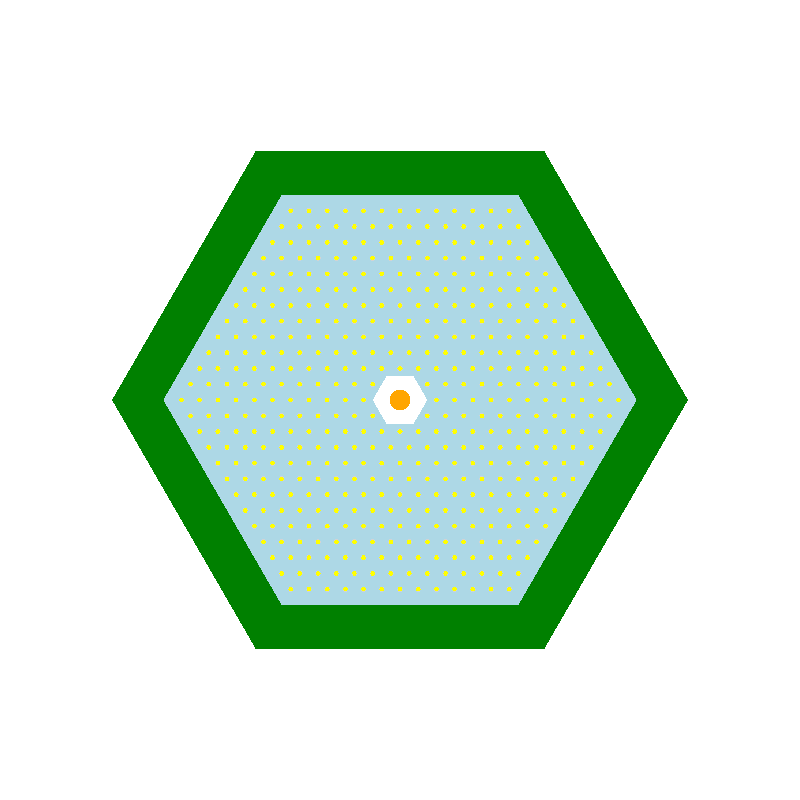

2. VISTA LATERALE (Piano XZ)


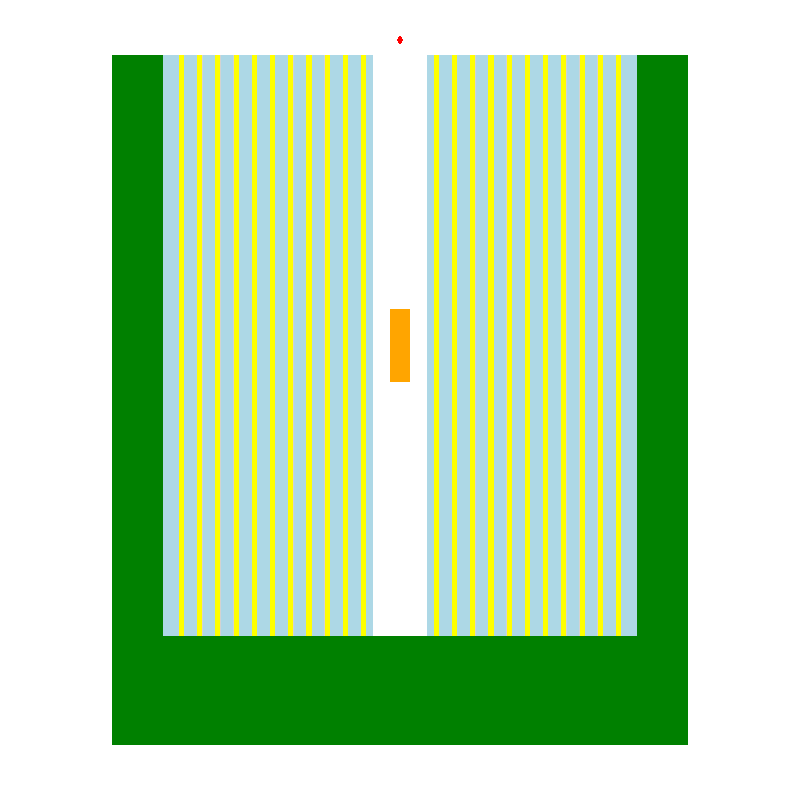


--- LEGENDA COLORI ---
■ yellow          : fuel
■ lightgray       : cladding
■ lightblue       : water
■ green           : reflector
■ red             : marker
■ white           : void_air
■ orange          : mat_target


In [22]:
color_map = {
    fuel: 'yellow',         # Combustibile
    cladding: 'lightgray',  # Cladding
    water: 'lightblue',     # Moderatore (acqua)
    reflector: 'green',     # Riflettore
    marker_mat: 'red' ,     # Marker sorgente
    void_air: 'white',      # Vuoto (aria)
    mat_target: 'orange'   # Target
}

# A. Vista dall'alto (Sezione nel mezzo del core)
p1 = openmc.Plot()
p1.basis = 'xy'
p1.origin = (0.0, 0.0, H_CORE / 2.0)
p1.width = (3 * (R_CORE + REF_SIDE + 2.0), 3 * (R_CORE + REF_SIDE + 2.0))
p1.pixels = (800, 800)
p1.color_by = 'material'
p1.colors = color_map
p1.filename = 'reactor_xy'

# B. Vista laterale (Sezione verticale XZ)
p2 = openmc.Plot()
p2.basis = 'xz'
p2.origin = (0.0, 0.0, (H_CORE - REF_BOT) / 2.0) 
p2.width = (3 * (R_CORE + REF_SIDE + 2.0), H_CORE + REF_BOT + 15.0)
p2.pixels = (800, 800)
p2.color_by = 'material'
p2.colors = color_map
p2.filename = 'reactor_xz'

# Esporto tutti i plot nel file XML
plots = openmc.Plots([p1, p2])
plots.export_to_xml()

# Eseguo il plotter: ho rimosso open_browser=False che causava l'errore
# OpenMC genererà i file .png basandosi sui nomi definiti (reactor_xy.png, ecc.)
openmc.plot_geometry() 

print("\n" + "="*30)
print("VISUALIZZAZIONE GEOMETRIA")
print("="*30 + "\n")

print("1. VISTA DALL'ALTO (Piano XY nel Core)")
display(Image('reactor_xy.png'))

print("2. VISTA LATERALE (Piano XZ)")
display(Image('reactor_xz.png'))

# Legenda finale
print("\n--- LEGENDA COLORI ---")
for mat, col in color_map.items():
    print(f"■ {col.ljust(15)} : {mat.name}")

SETTING EIGENVALUED

In [23]:
settings_k = openmc.Settings()
settings_k.run_mode = 'eigenvalue'
settings_k.batches = batches
settings_k.particles = particles
settings_k.inactive = inactive

# Sorgente spaziale uniforme limitata al volume del combustibile
# Definiamo un box che racchiude il core
lower_left = [-R_CORE, -R_CORE, 0.0]
upper_right = [R_CORE, R_CORE, H_CORE]

safe_fuel_x = R_PIPE + PITCH
initial_point = openmc.stats.Point((safe_fuel_x, 0.0, H_CORE / 2.0))

settings_k.source = openmc.IndependentSource(space=initial_point)

settings_k.temperature = {'method': 'interpolation'} # Per abilitare l'interpolazione delle temperature nei materiali, se supportata dalle tabelle di sezioni d'urto.

# Esportazione (sovrascrive settings.xml)
settings_k.export_to_xml()


In [24]:
now = datetime.now()
timestamp = now.strftime("\n\n------ SIMULAZIONE DEL %d/%m/%Y ALLE ORE %H:%M ------\n")
output_file = "result.txt"

# Inizializzazione Header
with open(output_file, "a") as f:
    f.write(timestamp)
    f.write("=== PARAMETRI DI SIMULAZIONE ===\n")
    f.write(f"Arricchimento: {arricchimento}\n")
    f.write(f"RAGGGIO CORE: {R_CORE} cm\n")
    f.write(f"REFLECTOR SIDE: {REF_SIDE} cm\n")
    f.write(f"REFLECTOR BOTTOM: {REF_BOT} cm\n")
    f.write(f"H_CORE: {H_CORE} cm\n")
    f.write(f"mix acqua: {mix:.2f}\n")
    f.write(f"R_PIPE (Soglia): {R_PIPE} cm\n")
    f.write(f"Geometria PIN (R_FUEL, CLAD, R_WATER): {R_FUEL}, {CLAD_THICK}, {R_WATER_THICK} cm\n")
    f.write(f"PITCH: {PITCH:.5f} cm\n")
    f.write(f"Target (R, H, Pos): {R_TARGET}, {H_TARGET}, {P_TARGET} cm\n")
    f.write(f"Settings: {batches} batches, {particles} particles, {inactive} inactive batches\n")
    f.write("================================\n\n")
    f.write(f"{'T_WATER [K]':<12} {'T_FUEL [K]':<12} {'K_EFF':<12} {'STD_DEV':<12}\n") # Intestazione Colonne

# Loop Annidati
for T_water in range(300, 600, 50):
    water.temperature = T_water
    
    for T in range(300, 1500, 50):
        print(f"Simulazione: H2O={T_water}K, Fuel={T}K")

        fuel.temperature = T
        cladding.temperature = T
        reflector.temperature = T
        mat_target.temperature = T

        # Export XML (Fondamentale dentro i loop se cambiano i valori)
        mats = openmc.Materials([fuel, cladding, water, reflector, marker_mat, void_air, mat_target])
        mats.cross_sections = "/home/bossi_ricky/openmc_data/mcnp_endfb71/cross_sections.xml"
        mats.export_to_xml()

        percorso_eseguibile = "/home/bossi_ricky/miniconda3/envs/openmc-env/bin/openmc"
        openmc.run(openmc_exec=percorso_eseguibile, output=False)

        sp_filename = f'statepoint.{batches}.h5'

        if os.path.exists(sp_filename):
            with openmc.StatePoint(sp_filename) as sp:
                k_val = sp.k_combined.nominal_value
                k_std = sp.k_combined.std_dev

                print(f"  Risultato: k = {k_val:.5f} +/- {k_std:.5f}")
                
                with open(output_file, "a") as f:
                    # Inserisco anche T_water per chiarezza nel file
                    f.write(f"{T_water:<12} {T:<12} {k_val:<12.5f} {k_std:<12.5f}\n")
            
            os.remove(sp_filename)
        
        if os.path.exists('summary.h5'):
            os.remove('summary.h5')

Simulazione: H2O=300K, Fuel=300K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


Simulazione: H2O=300K, Fuel=350K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


Simulazione: H2O=300K, Fuel=400K


...

/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


Simulazione: H2O=450K, Fuel=450K


/home/bossi_ricky/miniconda3/envs/openmc-env/lib/python3.11/site-packages/openmc/statepoint.py:287: FutureWarning: The 'k_combined' property has been renamed to 'keff' and will be removed in a future version of OpenMC.
  warnings.warn(


Simulazione: H2O=450K, Fuel=500K


KeyboardInterrupt: 

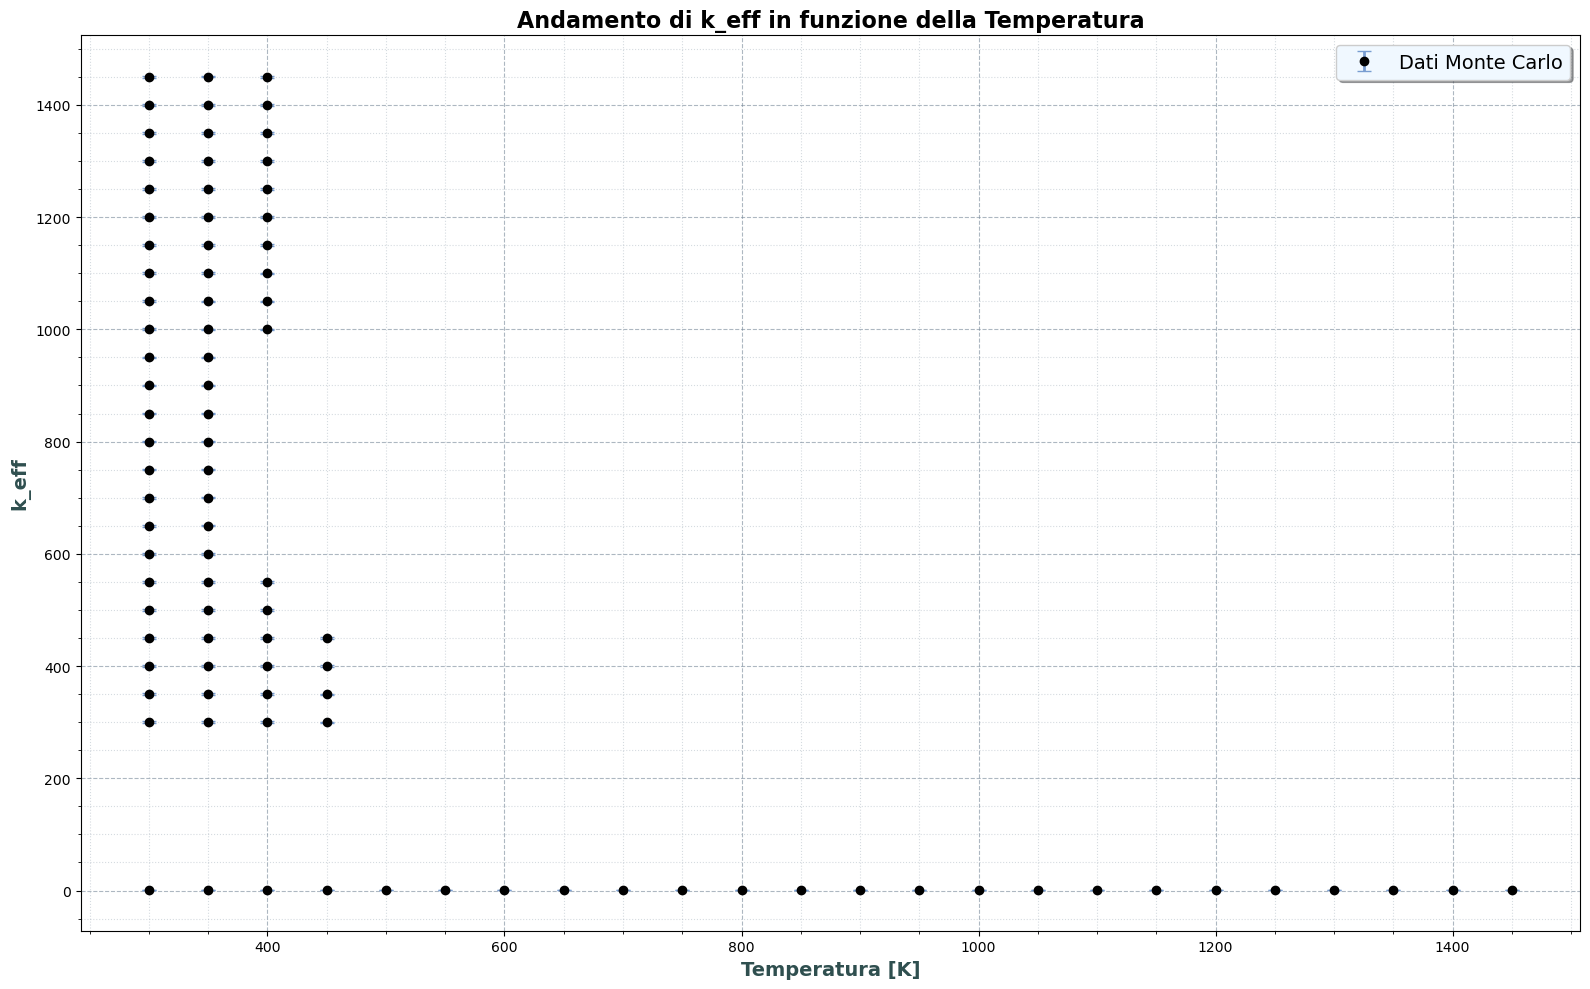

In [ ]:
# --- 1. LETTURA DEL FILE result.txt ---
filename = "single_sresult.txt"
temps = []
k_effs = []
stds = []

# Parser robusto: salta l'header e legge solo le righe che iniziano con numeri
with open(filename, 'r') as f:
    for line in f:
        line = line.strip()
        if not line: continue
        # Se il primo carattere è un numero, assumiamo sia una riga dati
        if line[0].isdigit():
            parts = line.split()
            if len(parts) >= 3:
                temps.append(float(parts[0]))
                k_effs.append(float(parts[1]))
                stds.append(float(parts[2]))

T_data = np.array(temps)
k_data = np.array(k_effs)
err_data = np.array(stds)

pcm = (k_data - 1)/(10e-5*k_data)

# --- 3. PLOTTING (Stile Unificato) ---
fig, ax = plt.subplots(figsize=(16, 10))

# Plot dei dati con barre d'errore
ax.errorbar(T_data, k_data, yerr=err_data, 
            fmt='o',                  # Punti senza linea di congiunzione
            color='#000000',          # Colore punti
            ecolor='#789DD1',         # Colore barre errore
            elinewidth=2,             # Spessore barre
            capsize=5,                # Cappuccetto barre
            label='Dati Monte Carlo',
            zorder=5)

# Formattazione Stile
font_labels = {'fontsize': 14, 'fontweight': 'bold', 'color': '#2F4F4F'}

ax.set_xlabel('Temperatura [K]', **font_labels)
ax.set_ylabel('k_eff', **font_labels)
ax.set_title('Andamento di k_eff in funzione della Temperatura', fontsize=16, fontweight='bold')

# Griglia
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Legenda
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=14, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()

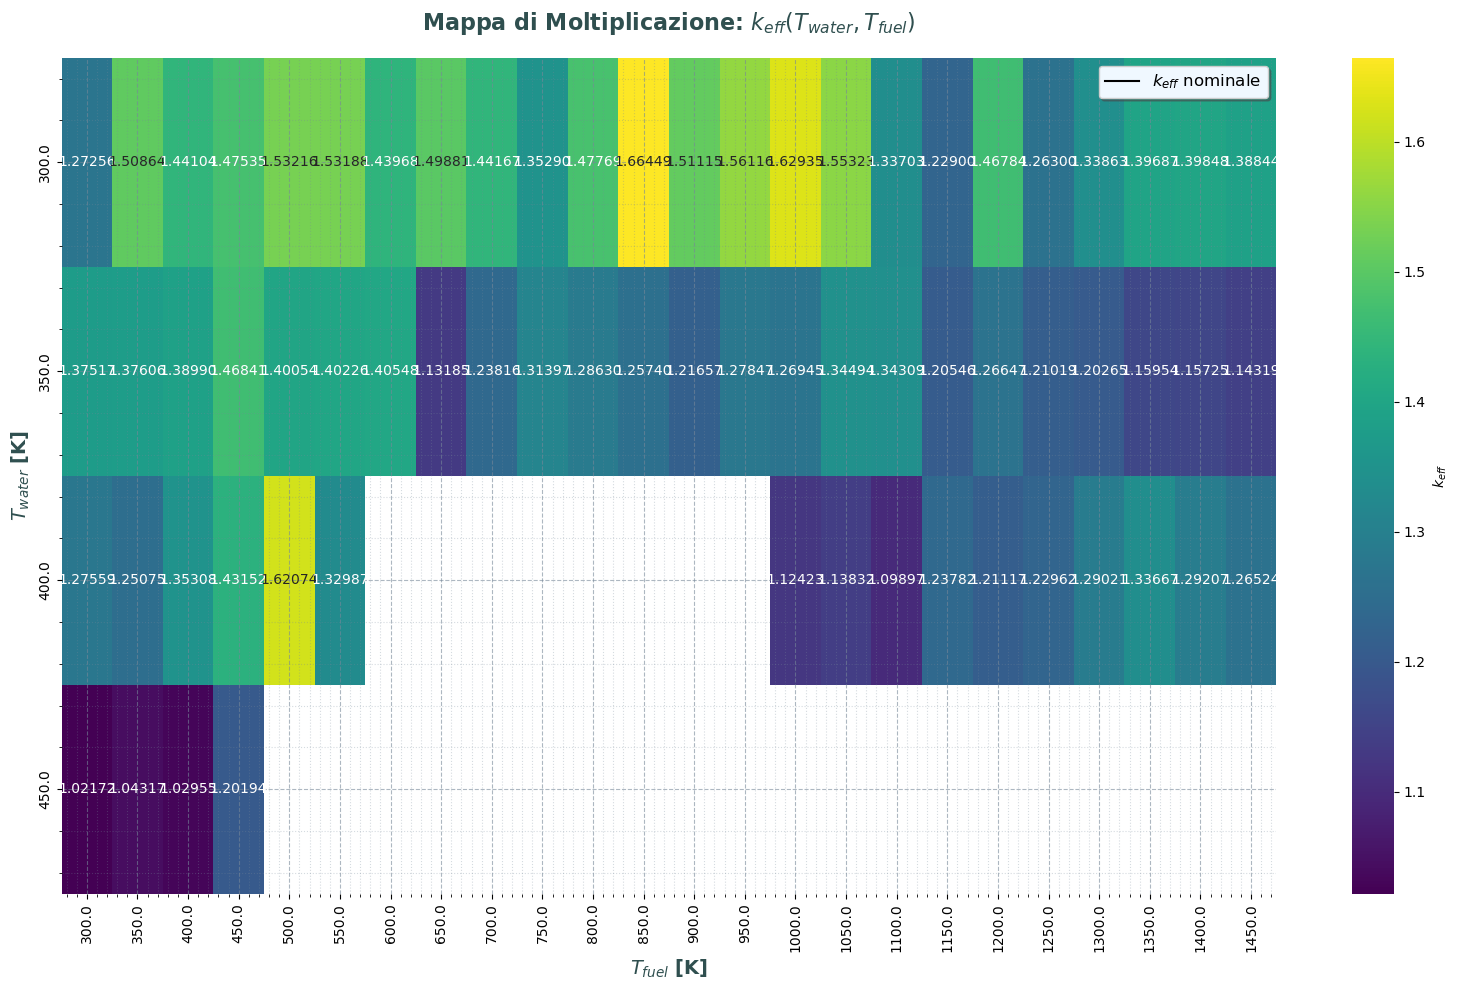

In [27]:
import pandas as pd
import seaborn as sns

# 1. Parsing robusto del file di output
data = []
with open("result.txt", "r") as f:
    for line in f:
        parts = line.strip().split()
        # Isolamento delle righe contenenti le 4 grandezze fisiche
        if len(parts) == 4:
            try:
                t_w = float(parts[0])
                t_f = float(parts[1])
                k = float(parts[2])
                err = float(parts[3])
                data.append([t_w, t_f, k, err])
            except ValueError:
                continue

df = pd.DataFrame(data, columns=['T_water', 'T_fuel', 'k_eff', 'std_dev'])

# 2. Vettorizzazione 2D per la heatmap
heatmap_data = df.pivot(index='T_water', columns='T_fuel', values='k_eff')

# 3. Setup del plot (Standard Layout)
fig, ax = plt.subplots(figsize=(16, 10))

# Mappatura termica
sns.heatmap(heatmap_data, annot=True, fmt=".5f", cmap="viridis", ax=ax,
            cbar_kws={'label': '$k_{eff}$'})

# Formattazione Titolo e Labels
ax.set_title("Mappa di Moltiplicazione: $k_{eff}(T_{water}, T_{fuel})$", fontsize=16, fontweight='bold', color='#2F4F4F', pad=20)
ax.set_xlabel("$T_{fuel}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')
ax.set_ylabel("$T_{water}$ [K]", fontsize=14, fontweight='bold', color='#2F4F4F')

# Impostazioni griglia customizzate
ax.minorticks_on()
ax.grid(which='major', linestyle='--', alpha=0.6, color='#778899')
ax.grid(which='minor', linestyle=':', alpha=0.3, color='#778899')

# Dummy plot per forzare l'inizializzazione della legenda con il tuo stile
ax.plot([], [], color='#000000', label='$k_{eff}$ nominale') 
ax.legend(loc='upper right', frameon=True, shadow=True, fontsize=12, facecolor='#F0F8FF')

plt.tight_layout()
plt.show()